# **01 - EDA**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

Загрузка и предпросмотр датасета:

In [6]:
import os
import pandas as pd

if os.path.exists('/content'):
    project_root = '/content'
else:
    project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

project_dirs = [
    'data/raw', 'data/processed', 'models', 'notebooks',
    'presentation', 'report/images', 'src', 'tests'
]

for d in project_dirs:
    os.makedirs(os.path.join(project_root, d), exist_ok=True)

raw_data_path = os.path.join(project_root, 'data/raw/Student Depression Dataset.csv')

possible_root_file = os.path.join(project_root, 'Student Depression Dataset.csv')
if os.path.exists(possible_root_file) and not os.path.exists(raw_data_path):
    os.rename(possible_root_file, raw_data_path)

try:
    df_depression = pd.read_csv(raw_data_path)
    print(f'Файл успешно загружен: {raw_data_path}')
    display(df_depression.head())
except Exception as e:
    print(f'Ошибка при загрузке: {e}')
    print(f'Пожалуйста, убедитесь, что файл лежит по адресу: {raw_data_path}')

Файл успешно загружен: /content/data/raw/Student Depression Dataset.csv


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


Описание датасета:

In [ ]:
print(f"Размер датасета: {df_depression.shape[0]} строк и {df_depression.shape[1]} столбцов.")

print("\nОбщая информация о датасете:")
df_depression.info()

print("\nОсновные статистические характеристики числовых столбцов:")
display(df_depression.describe())

print("\nРаспределение целевой переменной 'Depression':")
display(df_depression['Depression'].value_counts(normalize=True))

Размер датасета: 27901 строк и 18 столбцов.

Общая информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27898.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437347,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000



Распределение целевой переменной 'Depression':


,proportion
Depression,
1,0.585499
0,0.414501


Очистка данных:

In [ ]:
print("Пропущенные значения до обработки:")
display(df_depression.isnull().sum()[df_depression.isnull().sum() > 0])

initial_shape = df_depression.shape[0]
df_depression.dropna(inplace=True)
final_shape = df_depression.shape[0]

print(f"\nУдалено строк с пропусками: {initial_shape - final_shape}")
print(f"Размер датасета после удаления пропусков: {df_depression.shape[0]} строк.")

print("\nПропущенные значения после обработки:")
display(df_depression.isnull().sum()[df_depression.isnull().sum() > 0])

initial_rows = df_depression.shape[0]
df_depression.drop_duplicates(inplace=True)
final_rows = df_depression.shape[0]
print(f"\nКоличество удаленных дубликатов: {initial_rows - final_rows}")
print(f"Размер датасета после удаления дубликатов: {df_depression.shape[0]} строк.")

Пропущенные значения до обработки:


,0
Financial Stress,3



Удалено строк с пропусками: 3
Размер датасета после удаления пропусков: 27898 строк.

Пропущенные значения после обработки:


,0



Количество удаленных дубликатов: 0
Размер датасета после удаления дубликатов: 27898 строк.


Приведение типов данных:

In [ ]:
categorical_cols = ['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']
for col in categorical_cols:
    df_depression[col] = df_depression[col].astype('category')

ordinal_cols = [
    'Academic Pressure',
    'Work Pressure',
    'Study Satisfaction',
    'Job Satisfaction',
    'Work/Study Hours',
    'Financial Stress'
]

print("\nТипы данных после преобразования:")
df_depression.info()


Типы данных после преобразования:
<class 'pandas.core.frame.DataFrame'>
Index: 27898 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   id                                     27898 non-null  int64   
 1   Gender                                 27898 non-null  category
 2   Age                                    27898 non-null  float64 
 3   City                                   27898 non-null  category
 4   Profession                             27898 non-null  category
 5   Academic Pressure                      27898 non-null  float64 
 6   Work Pressure                          27898 non-null  float64 
 7   CGPA                                   27898 non-null  float64 
 8   Study Satisfaction                     27898 non-null  float64 
 9   Job Satisfaction                       27898 non-null  float64 
 10  Sleep Duration              

Работа с фичами:

In [ ]:
initial_features_count = df_depression.shape[1] - 2
print(f"Исходное количество признаков: {initial_features_count}")

print("\nУникальные значения и их количество для категориальных признаков:")
if 'categorical_cols' not in locals() and 'categorical_cols' not in globals():
    categorical_cols = ['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df_depression[col].value_counts())

df_depression['Overall_Pressure'] = df_depression['Academic Pressure'] + df_depression['Work Pressure']

df_depression['Satisfaction_Ratio'] = df_depression['Study Satisfaction'] / (df_depression['Job Satisfaction'] + 1e-6) # Добавляем малое число, чтобы избежать деления на ноль

print(f"\nКоличество признаков после добавления новых: {df_depression.shape[1] - 2}")

# Выведем первые строки с новыми признаками
print("\nДатасет с новыми признаками (первые 5 строк):")
display(df_depression.head())

Исходное количество признаков: 16

Уникальные значения и их количество для категориальных признаков:

--- Gender ---
Gender
Male      15546
Female    12352
Name: count, dtype: int64

--- City ---
City
Kalyan                1570
Srinagar              1372
Hyderabad             1339
Vasai-Virar           1290
Lucknow               1155
Thane                 1139
Ludhiana              1111
Agra                  1094
Surat                 1078
Kolkata               1065
Jaipur                1036
Patna                 1007
Visakhapatnam          969
Pune                   968
Ahmedabad              951
Bhopal                 934
Chennai                885
Meerut                 825
Rajkot                 816
Delhi                  768
Bangalore              767
Ghaziabad              745
Mumbai                 699
Vadodara               694
Varanasi               684
Nagpur                 651
Indore                 643
Kanpur                 609
Nashik                 547
Faridabad       

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,Overall_Pressure,Satisfaction_Ratio
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1,5.0,2000000.0
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0,2.0,5000000.0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0,3.0,5000000.0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1,3.0,2000000.0
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0,4.0,3000000.0


Визуализация и графики:

Распределение целевой переменной

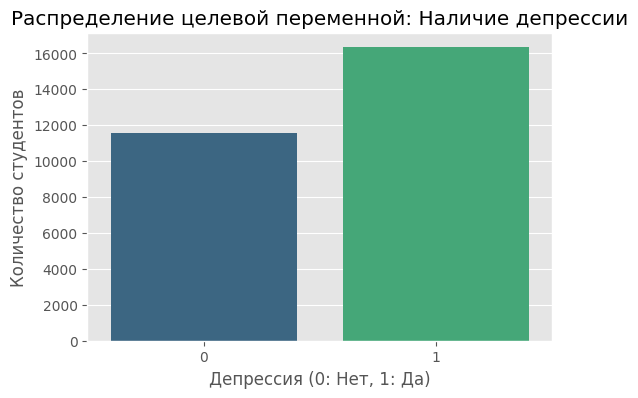

In [ ]:
plt.style.use('ggplot')

# Распределение целевой переменной 'Depression'
plt.figure(figsize=(6, 4))
sns.countplot(x='Depression', data=df_depression, palette='viridis', hue='Depression', legend=False)
plt.title('Распределение целевой переменной: Наличие депрессии')
plt.xlabel('Депрессия (0: Нет, 1: Да)')
plt.ylabel('Количество студентов')
plt.show()

Распределение ключевых числовых признаков

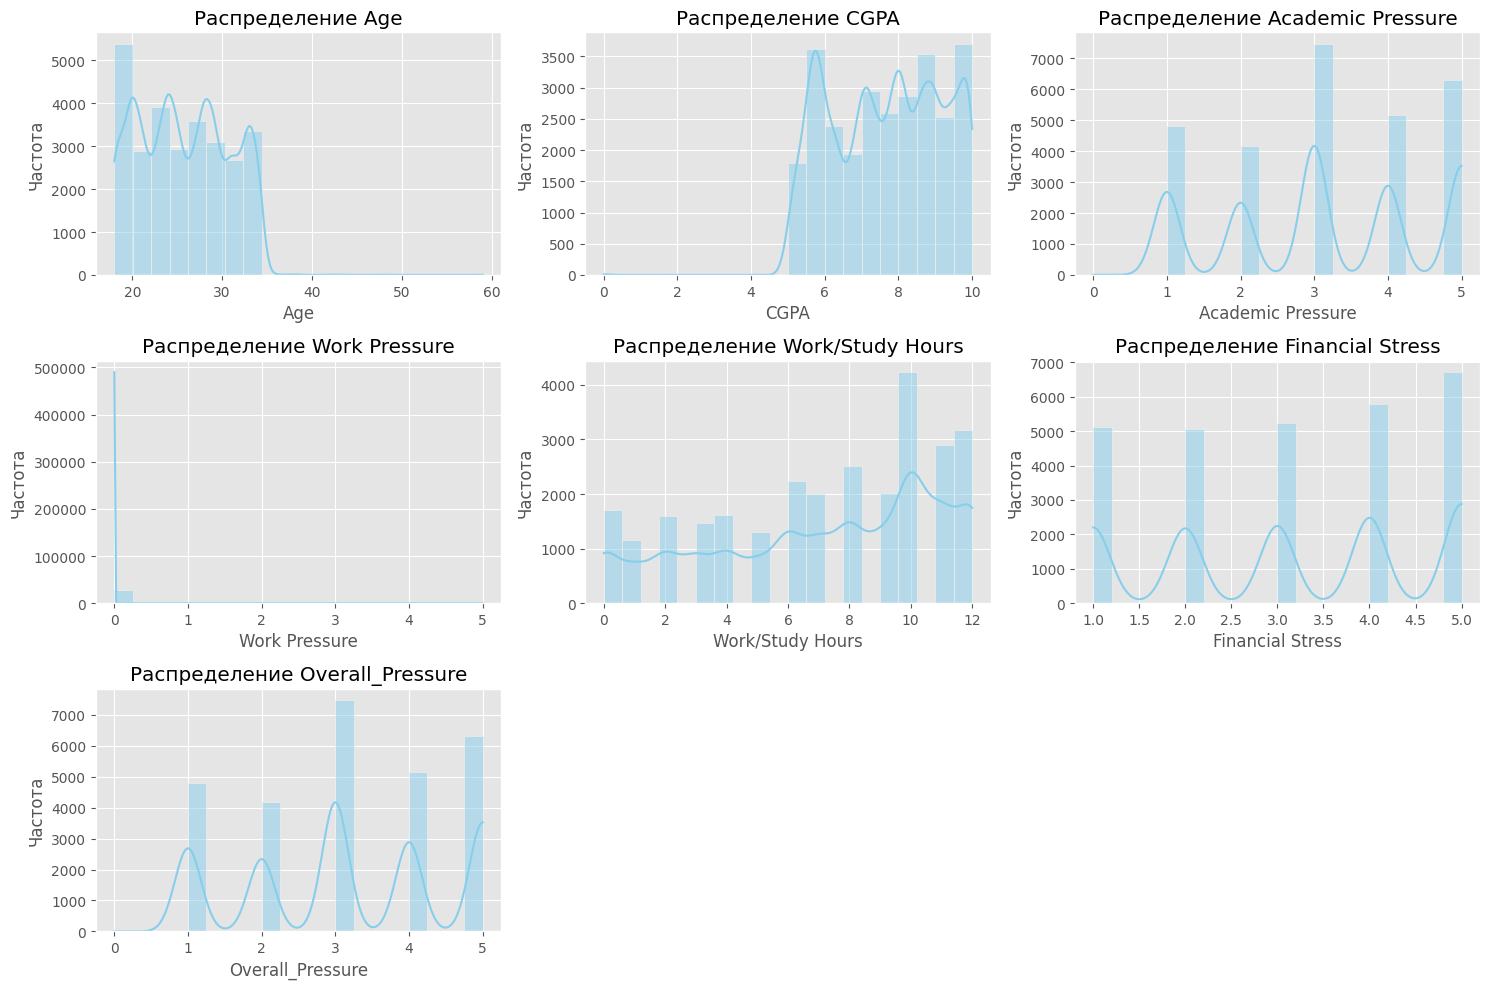

In [ ]:
numerical_cols_for_eda = [
    'Age', 'CGPA', 'Academic Pressure', 'Work Pressure',
    'Work/Study Hours', 'Financial Stress', 'Overall_Pressure'
]

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_eda):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of features
    sns.histplot(df_depression[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Распределение {col}')
    plt.xlabel(col)
    plt.ylabel('Частота')
plt.tight_layout()
plt.show()

Распределение категориальных признаков

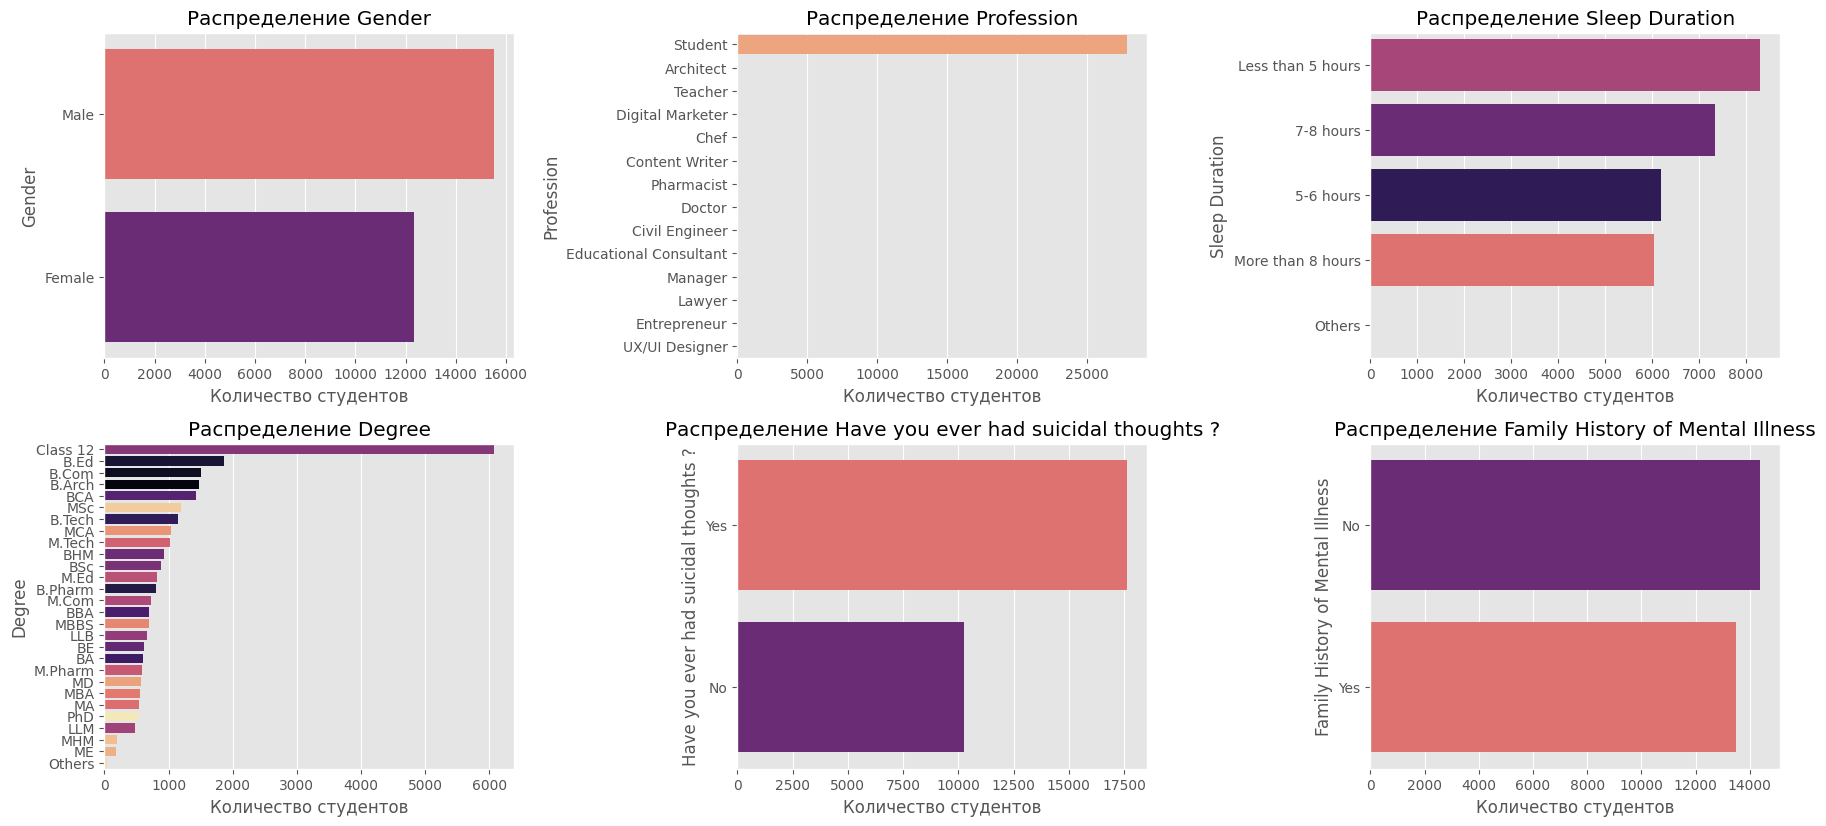

In [ ]:
categorical_cols_for_eda = [
    'Gender', 'Profession', 'Sleep Duration', 'Degree',
    'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness'
]

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols_for_eda):
    plt.subplot(3, 3, i + 1)
    sns.countplot(y=col, data=df_depression, palette='magma', order=df_depression[col].value_counts().index, hue=col, legend=False)
    plt.title(f'Распределение {col}')
    plt.xlabel('Количество студентов')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

Взаимосвязь признаков с целевой переменной

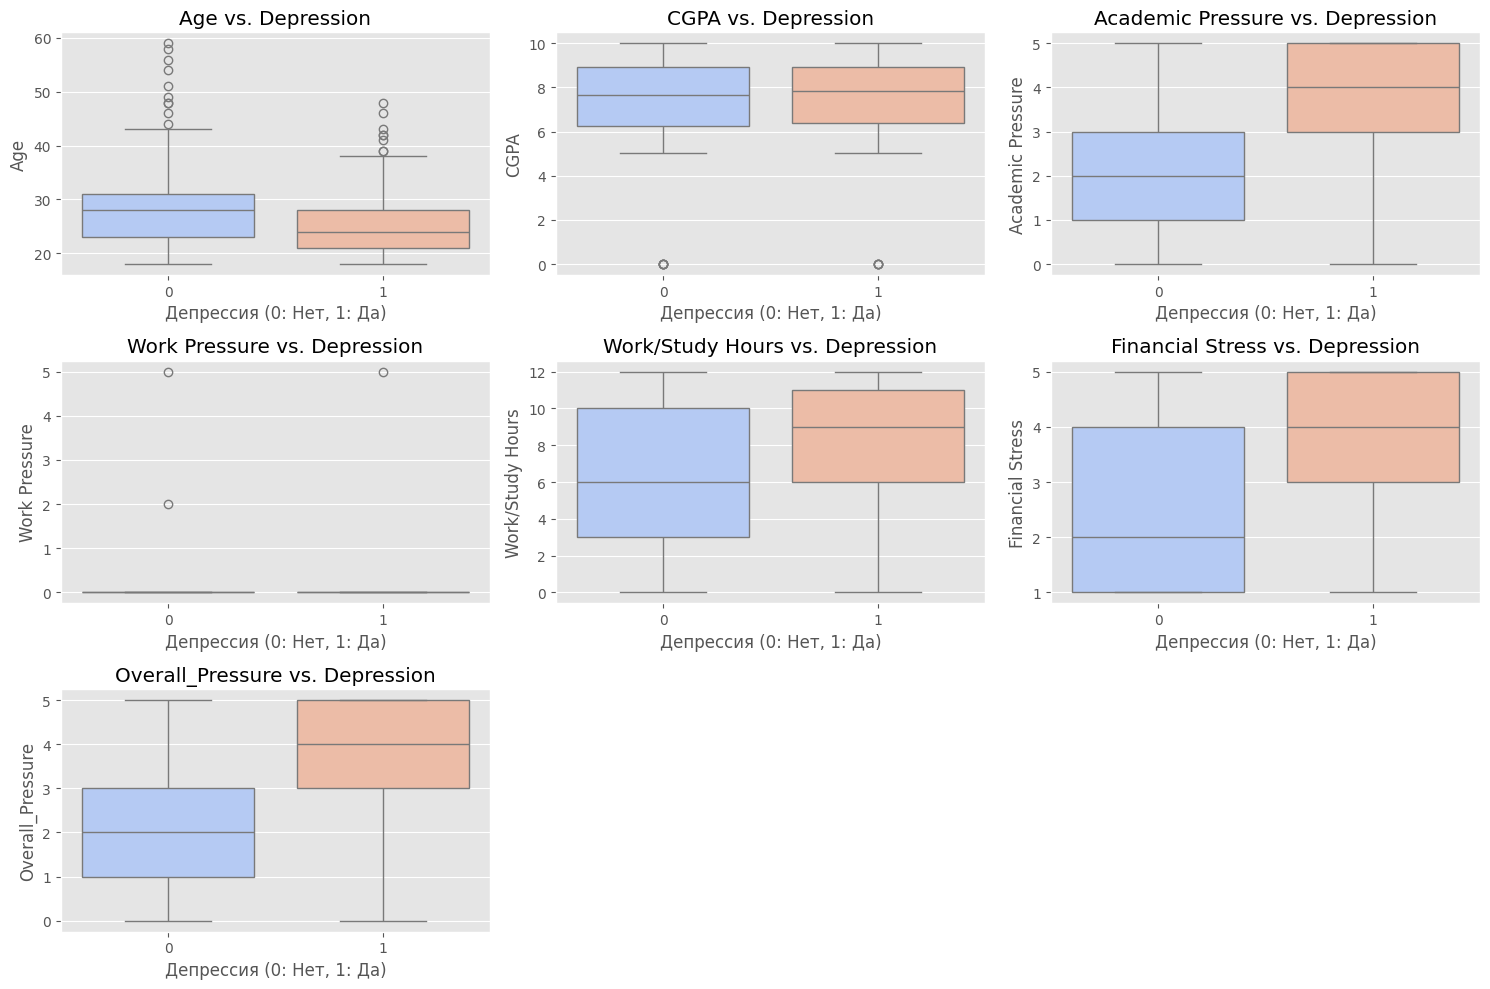

In [ ]:
if 'numerical_cols_for_eda' not in locals() and 'numerical_cols_for_eda' not in globals():
    numerical_cols_for_eda = [
        'Age', 'CGPA', 'Academic Pressure', 'Work Pressure',
        'Work/Study Hours', 'Financial Stress', 'Overall_Pressure'
    ]

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_eda):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x='Depression', y=col, data=df_depression, palette='coolwarm', hue='Depression', legend=False)
    plt.title(f'{col} vs. Depression')
    plt.xlabel('Депрессия (0: Нет, 1: Да)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

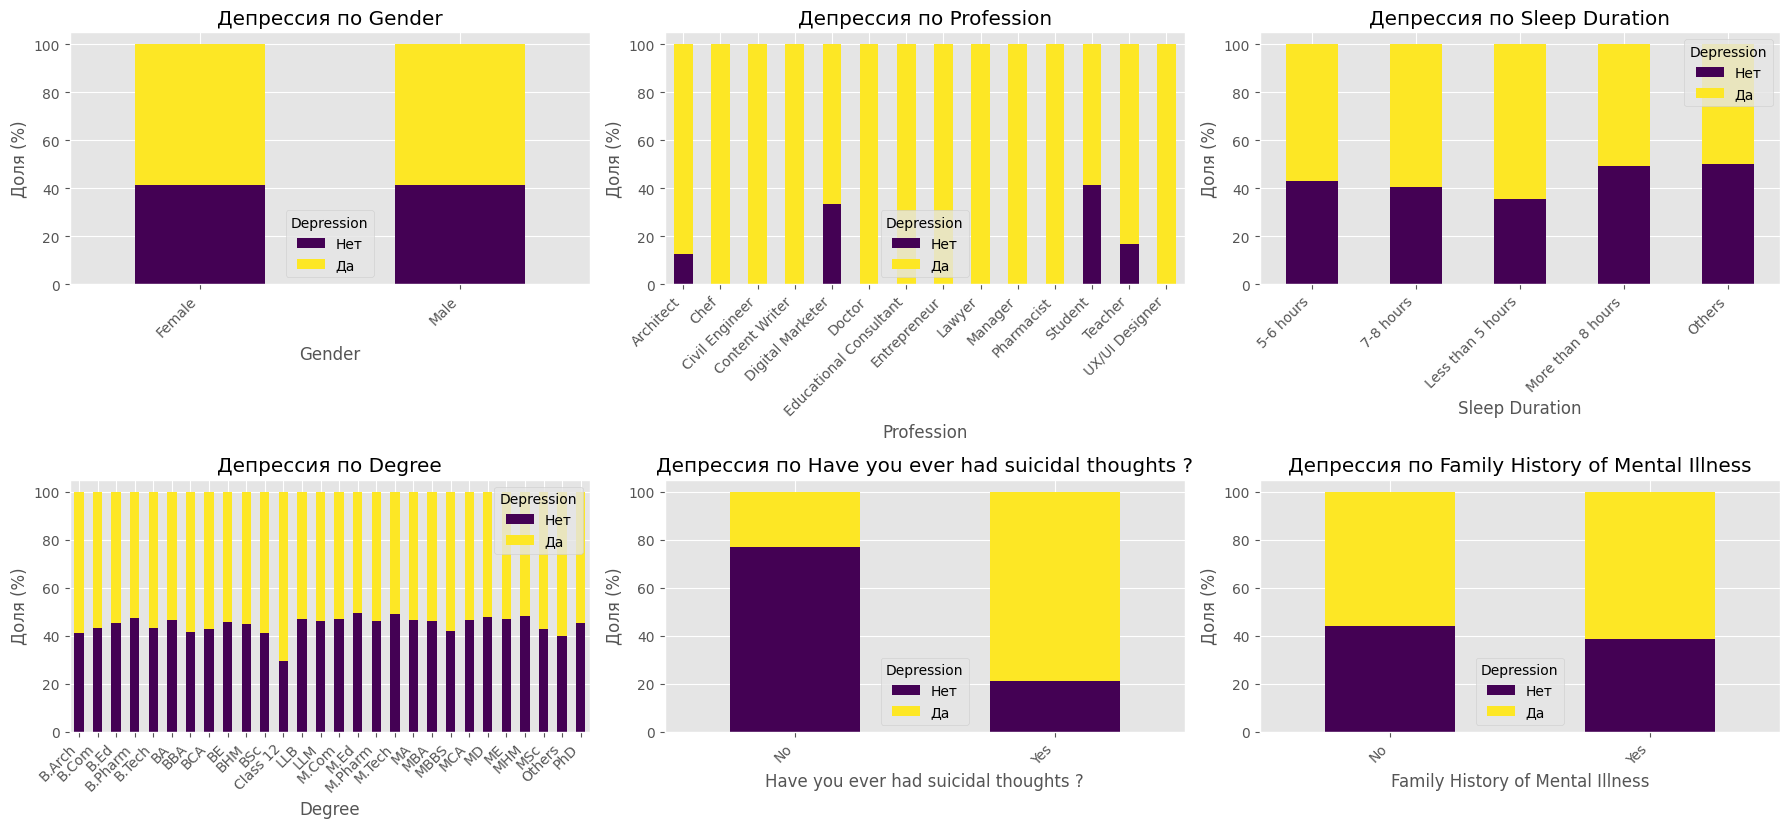

In [ ]:
if 'categorical_cols_for_eda' not in locals() and 'categorical_cols_for_eda' not in globals():
    categorical_cols_for_eda = [
        'Gender', 'Profession', 'Sleep Duration', 'Degree',
        'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness'
    ]

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols_for_eda):
    plt.subplot(3, 3, i + 1)
    # Создаем crosstab для подсчета долей
    cross_tab = pd.crosstab(df_depression[col], df_depression['Depression'], normalize='index') * 100
    cross_tab.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())
    plt.title(f'Депрессия по {col}')
    plt.xlabel(col)
    plt.ylabel('Доля (%)')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Depression', labels=['Нет', 'Да'])
plt.tight_layout()
plt.show()

Матрица корреляции

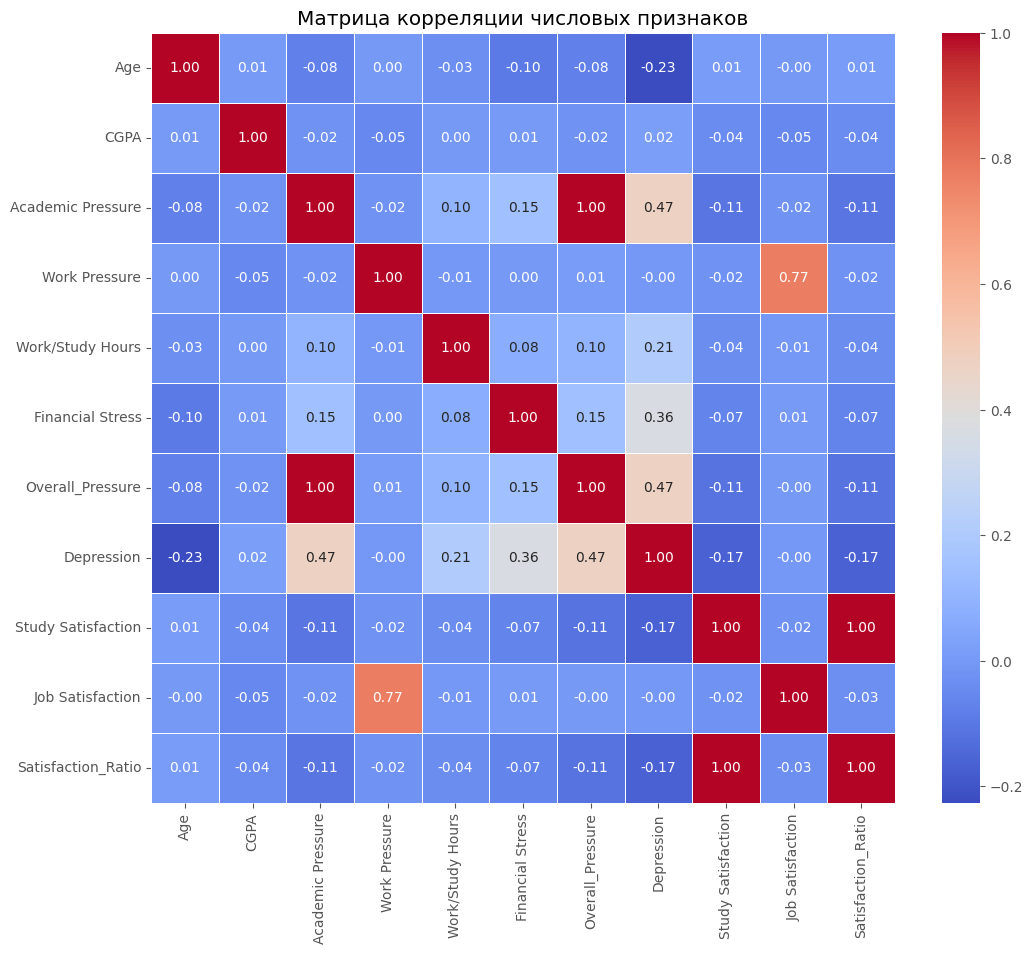

In [ ]:
if 'numerical_cols_for_eda' not in locals() and 'numerical_cols_for_eda' not in globals():
    numerical_cols_for_eda = [
        'Age', 'CGPA', 'Academic Pressure', 'Work Pressure',
        'Work/Study Hours', 'Financial Stress', 'Overall_Pressure'
    ]

correlation_features = numerical_cols_for_eda + ['Depression', 'Study Satisfaction', 'Job Satisfaction', 'Satisfaction_Ratio']
correlation_matrix = df_depression[correlation_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Матрица корреляции числовых признаков')
plt.show()

# Разделение данных и предотвращение утечек
**Удаление неинформативных признаков:** Мы удаляем id, так как он может содержать случайные корреляции.

**Сплит перед финальной обработкой:** Мы разделяем данные на Train (70%), Val (15%) и Test (15%) до применения кодирования категориальных признаков (Label Encoding/One-Hot), чтобы информация о категориях из тестовой выборки не попала в обучающую.

**Сохранение файлов:** Разделяем данные на raw (исходный датасет) и processed (готовые для модели тензоры/матрицы).

In [ ]:
from sklearn.model_selection import train_test_split
import os

os.makedirs('data/processed', exist_ok=True)
os.makedirs('data/raw', exist_ok=True)

df_depression.to_csv('data/raw/student_depression_raw.csv', index=False)

X = df_depression.drop(columns=['id', 'Depression'])
y = df_depression['Depression']

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, random_state=42, stratify=y_train_val
)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер валидационной выборки: {X_val.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

X_train.assign(Depression=y_train).to_csv('data/processed/train.csv', index=False)
X_val.assign(Depression=y_val).to_csv('data/processed/val.csv', index=False)
X_test.assign(Depression=y_test).to_csv('data/processed/test.csv', index=False)

print("\nФайлы успешно сохранены в data/processed/")

Размер обучающей выборки: 19527
Размер валидационной выборки: 4186
Размер тестовой выборки: 4185

Файлы успешно сохранены в data/processed/
